# Simulating flux from casks

As described in the [introduction](../about.md), the main goal of this package is to simulate the antineutrino flux emitted by spent nuclear fuel (SNF) casks. This is done using two main classes: {py:obj}`Spectrum <snf_simulations.spec.Spectrum>` and {py:obj}`Cask <snf_simulations.cask.Cask>`, which are defined in the {py:obj}`snf_simulations.spec <snf_simulations.spec>` and {py:obj}`snf_simulations.cask <snf_simulations.cask>` modules, respectively.

Once we've created a `Cask` object, we can use the {py:func}`get_total_spectrum <snf_simulations.cask.Cask.get_total_spectrum>` method to create a `Spectrum` object representing the combined antineutrino spectrum from all isotopes in the cask.

In [6]:
from snf_simulations.cask import Cask

# Create a Cask object for 10 tonnes of SNF from the Sizewell reactor
cask = Cask.from_tabqfile('example.tbQ', total_mass=10000, name='Sizewell')
print(cask)

cooling_time = 0.5  # years
total_spec = cask.get_total_spectrum(cooling_time=cooling_time)
print(total_spec)

<Cask "Sizewell": 16 isotopes, cooling time=2.738e-03 years>
<Spectrum "Sizewell": energy_range=(0.0-5313.0 keV)>


## Measuring the flux at a distance

We can get a measure for the total antineutrino flux above a given energy threshold by integrating the the total spectrum. For inverse beta decay the threshold is 1.806 MeV, so we integrate above this energy to get the total flux of antineutrinos that can be detected.

In [8]:
total_flux = total_spec.integrate(lower_energy=1806)
print(f"Total flux above 1.806 MeV: {total_flux:.3e} per second")

Total flux above 1.806 MeV: 2.104e+17 per second


This is the total flux emitted in all directions. To get the flux at a given distance from the cask, we can then use the {py:obj}`calculate_flux_at_distance <snf_simulations.physics.calculate_flux_at_distance>` function from the {py:obj}`snf_simulations.physics <snf_simulations.physics>` module, which takes the total flux and the distance as arguments. It calculates the flux using the inverse square law:

$$F(d) = \frac{F_{tot}}{4 \pi d^2}$$

where $F(d)$ is the flux at distance $d$, and $F_{tot}$ is the total flux emitted by the cask isotropically.

In [9]:
from snf_simulations.physics import calculate_flux_at_distance

distance = 40  # meters
flux_at_40m = calculate_flux_at_distance(total_flux, distance)

print(
    f"Single 10-tonne {cask.name} cask "
    f"at {distance}m after {cooling_time:.1f} years:"
)
print("Antineutrino flux:")
print(f"  {flux_at_40m:.3e} per cm2 per second")
print(f"  {flux_at_40m * 60 * 60 * 24:.3e} per cm2 per day")

Single 10-tonne Sizewell cask at 40m after 0.5 years:
Antineutrino flux:
  1.046e+09 per cm2 per second
  9.042e+13 per cm2 per day


## Simulating events in a detector

Finally, we can calculate how that flux would convert into the number of events in our detector using the {py:func}`calculate_event_rate <snf_simulations.physics.calculate_event_rate>` function.

:::{note}
At the moment only the VIDARR detector is supported. See [this GitHub Issue](https://github.com/ekneale/SNF-simulations/issues/26) for details.
:::

In [10]:
from snf_simulations.physics import calculate_event_rate

rate_lower, rate_upper = calculate_event_rate(flux_at_40m, 0.2, 0.4)
print("Event rate in VIDARR detector:")
print(f"  {rate_lower:.3e} to {rate_upper:.3e} per second")
print(f"  {rate_lower * 60 * 60 * 24:.3f} to {rate_upper * 60**2 * 24:.3f} per day")

Event rate in VIDARR detector:
  1.557e-07 to 3.114e-07 per second
  0.013 to 0.027 per day


We can plot how the event rate varies with distance from the cask.

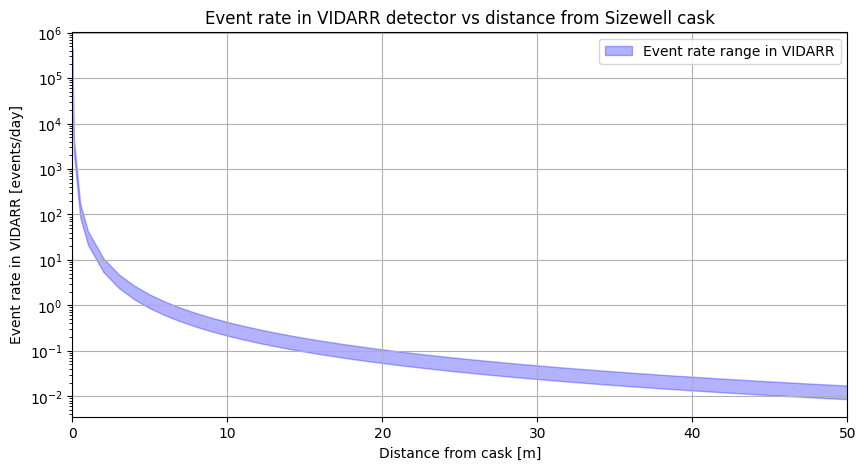

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Get a range of distances
distances = np.concatenate(([0.01, 0.05, 0.1, 0.5], np.linspace(1, 50, 50)))
cooling_time = 0.5  # years

total_spec = cask.get_total_spectrum(cooling_time=cooling_time)
total_flux = total_spec.integrate(lower_energy=1806)
event_rates = []
for distance in distances:
    flux_at_distance = calculate_flux_at_distance(total_flux, distance)
    rate_lower, rate_upper = calculate_event_rate(flux_at_distance, 0.2, 0.4)
    event_rates.append((rate_lower * 60 * 60 * 24, rate_upper * 60 * 60 * 24))
event_rates = np.array(event_rates)

figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)
axes.fill_between(
    distances,
    event_rates[:, 0],
    event_rates[:, 1],
    color="blue",
    alpha=0.3,
    label="Event rate range in VIDARR",
)
axes.set_xlim(0, 50)
axes.set_xlabel("Distance from cask [m]")
axes.set_ylabel("Event rate in VIDARR [events/day]")
axes.set_title(
    f"Event rate in VIDARR detector vs distance from {cask.name} cask"
)
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()

Or we could plot how the event rate varies with time after removal from the reactor.

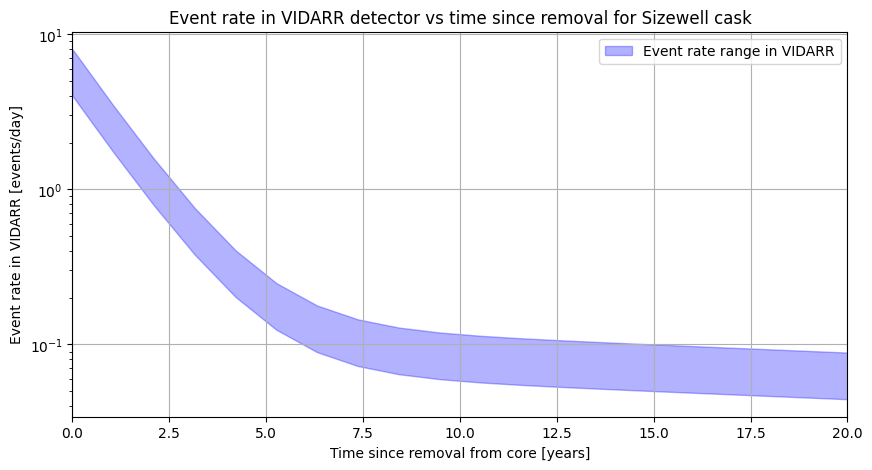

In [ ]:
cooling_times = np.linspace(0, 20, 20)  # years
distance = 40  # meters

event_rates = []
for cooling_time in cooling_times:
    if cooling_time == 0:
        # Since minimum cooling time is 24 hours, we can't ask for 0.
        # Here the default will use the 24 hour time.
        total_spec = cask.get_total_spectrum()
    else:
        total_spec = cask.get_total_spectrum(cooling_time=cooling_time)
    total_flux = total_spec.integrate(lower_energy=1806)
    flux_at_distance = calculate_flux_at_distance(total_flux, distance)
    rate_lower, rate_upper = calculate_event_rate(flux_at_distance, 0.2, 0.4)
    event_rates.append((rate_lower * 60 * 60 * 24, rate_upper * 60 * 60 * 24))
event_rates = np.array(event_rates)

figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)
axes.fill_between(
    cooling_times,
    event_rates[:, 0],
    event_rates[:, 1],
    color="blue",
    alpha=0.3,
    label="Event rate range in VIDARR",
)
axes.set_xlim(0, 20)
axes.set_xlabel("Time since removal from core [years]")
axes.set_ylabel("Event rate in VIDARR [events/day]")
axes.set_title(
    f"Event rate in VIDARR detector vs time since removal "
    f"for {cask.name} cask"
)
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()